<a href="https://colab.research.google.com/github/jawadwali3454/AI-AND-ML/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (6).zip to archive (6).zip


In [4]:
import os

os.listdir()
!unzip "archive (6).zip"

Archive:  archive (6).zip
  inflating: SVMtrain.csv            


In [53]:
import pandas as pd

# Load the dataset
df = pd.read_csv('SVMtrain.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Male,22.0,1,0,7.2500,3
1,2,1,1,female,38.0,1,0,71.2833,1
2,3,1,3,female,26.0,0,0,7.9250,3
3,4,1,1,female,35.0,1,0,53.1000,3
4,5,0,3,Male,35.0,0,0,8.0500,3


In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,3
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,3
3,4,1,1,1,35.0,1,0,53.1000,3
4,5,0,3,0,35.0,0,0,8.0500,3


In [55]:
# checking encode
df['Sex'].unique()

array([0, 1])

In [56]:
# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all'))


Descriptive Statistics:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,0.350956,35.686355,0.524184,0.382452,32.096681,2.535433
std,256.998173,0.486260,0.834700,0.477538,17.756733,1.103705,0.806761,49.697504,0.792088
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,224.000000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.895800,2.000000
50%,446.000000,0.000000,3.000000,0.000000,32.000000,0.000000,0.000000,14.454200,3.000000
75%,668.000000,1.000000,3.000000,1.000000,54.000000,1.000000,0.000000,31.000000,3.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,3.000000


In [57]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


In [58]:
# Based on the output of df.isnull().sum(), we can handle missing values.
# For example, let's impute missing 'Age' values with the median.
# (Assuming 'Age' is the primary column with missing values based on typical Titanic datasets)
# If other columns have missing values, a similar approach or other imputation strategies can be applied.

# Check if 'Age' has missing values and impute if necessary
if df['Age'].isnull().any():
    median_age = df['Age'].median()
    df['Age'].fillna(median_age, inplace=True)
    print(f"\nMissing 'Age' values imputed with median: {median_age}")
else:
    print("\nNo missing 'Age' values found.")

# Re-check for missing values after imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())


No missing 'Age' values found.

Missing values after imputation:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


In [59]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# X = df.drop('Survived', axis=1) # Already done in cell wFEbu3AFSGHW
# y = df['Survived']             # Already done in cell wFEbu3AFSGHW

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (711, 8)
X_test shape: (178, 8)
y_train shape: (711,)
y_test shape: (178,)


### Applying SMOTE for Data Balancing

Since the dataset was unbalanced, we will apply the Synthetic Minority Over-sampling Technique (SMOTE) to the training data to balance the classes. This helps prevent the models from being biased towards the majority class.

In [60]:
from imblearn.over_sampling import SMOTE

smt = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smt.fit_resample(X_train, y_train)

print(f"Shape of X_train before SMOTE: {X_train.shape}")
print(f"Shape of y_train before SMOTE: {y_train.shape}")
print(f"Class distribution in y_train before SMOTE:\n{y_train.value_counts()}")

print(f"\nShape of X_train after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train after SMOTE: {y_train_resampled.shape}")
print(f"Class distribution in y_train after SMOTE:\n{y_train_resampled.value_counts()}")

Shape of X_train before SMOTE: (711, 8)
Shape of y_train before SMOTE: (711,)
Class distribution in y_train before SMOTE:
Survived
0    440
1    271
Name: count, dtype: int64

Shape of X_train after SMOTE: (880, 8)
Shape of y_train after SMOTE: (880,)
Class distribution in y_train after SMOTE:
Survived
1    440
0    440
Name: count, dtype: int64



--- Support Vector Machine (SVM) Model Evaluation with SMOTE ---
Accuracy: 0.6966

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.95      0.79       109
           1       0.80      0.29      0.43        69

    accuracy                           0.70       178
   macro avg       0.74      0.62      0.61       178
weighted avg       0.73      0.70      0.65       178



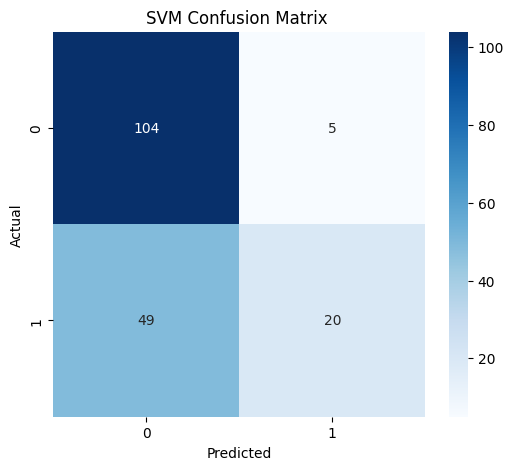

In [65]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the SVM classifier
svm_model_smote = SVC(random_state=42)

# Train the model on SMOTE-resampled data
svm_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test set
y_pred_svm_smote = svm_model_smote.predict(X_test)

# Evaluate the model
print("\n--- Support Vector Machine (SVM) Model Evaluation with SMOTE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_smote))

# Confusion Matrix
cm_svm_smote = confusion_matrix(y_test, y_pred_svm_smote)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_svm_smote, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


--- Decision Tree Classifier Model Evaluation (with SMOTE) ---
Accuracy: 0.7303

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.72      0.76       109
           1       0.63      0.75      0.68        69

    accuracy                           0.73       178
   macro avg       0.72      0.73      0.72       178
weighted avg       0.75      0.73      0.73       178



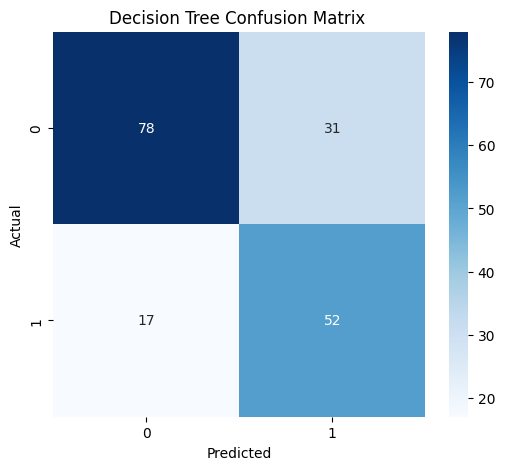

In [63]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree classifier
dt_model_smote = DecisionTreeClassifier(random_state=42)

# Train the model on SMOTE-resampled data
dt_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test set
y_pred_dt_smote = dt_model_smote.predict(X_test)

# Evaluate the model
print("\n--- Decision Tree Classifier Model Evaluation (with SMOTE) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_smote))

# Confusion Matrix
cm_dt_smote = confusion_matrix(y_test, y_pred_dt_smote)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt_smote, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


--- Random Forest Classifier Model Evaluation 
Accuracy: 0.7697

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       109
           1       0.69      0.72      0.71        69

    accuracy                           0.77       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.77      0.77       178



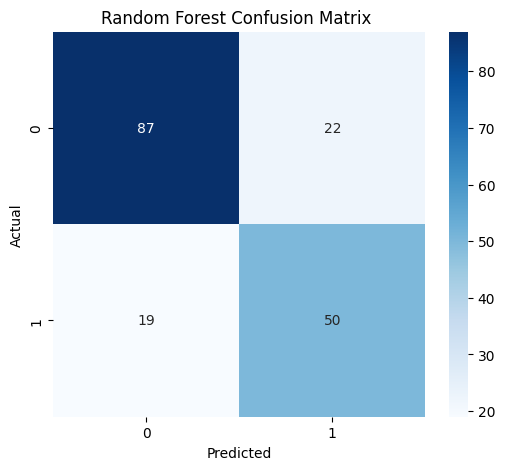

In [67]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest classifier
rf_model_smote = RandomForestClassifier(random_state=42)

# Train the model on SMOTE-resampled data
rf_model_smote.fit(X_train_resampled, y_train_resampled)

# Make predictions on the original test set
y_pred_rf_smote = rf_model_smote.predict(X_test)

# Evaluate the model
print("\n--- Random Forest Classifier Model Evaluation ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_smote))

# Confusion Matrix
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf_smote, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
# Get metrics for each SMOTE-trained model
svm_metrics_smote = get_metrics(y_test, y_pred_svm_smote, 'SVM ')
dt_metrics_smote = get_metrics(y_test, y_pred_dt_smote, 'Decision Tree')
rf_metrics_smote = get_metrics(y_test, y_pred_rf_smote, 'Random Forest')

# Create a DataFrame for comparison
comparison_df_smote = pd.DataFrame([svm_metrics_smote, dt_metrics_smote, rf_metrics_smote])

# Set Model name as index for better readability
comparison_df_smote = comparison_df_smote.set_index('Model')

print("\n--- Model Performance Comparison (with SMOTE) ---")
display(comparison_df_smote)


--- Model Performance Comparison (with SMOTE) ---


,Accuracy,Precision (Class 0),Recall (Class 0),F1-Score (Class 0),Support (Class 0),Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Support (Class 1),Macro Avg Precision,Macro Avg Recall,Macro Avg F1-Score,Weighted Avg Precision,Weighted Avg Recall,Weighted Avg F1-Score
Model,,,,,,,,,,,,,,,
SVM,0.696629,0.679739,0.954128,0.793893,109.0,0.800000,0.289855,0.425532,69.0,0.739869,0.621992,0.609713,0.726357,0.696629,0.651101
Decision Tree,0.730337,0.821053,0.715596,0.764706,109.0,0.626506,0.753623,0.684211,69.0,0.723779,0.734610,0.724458,0.745638,0.730337,0.733503
Random Forest,0.769663,0.820755,0.798165,0.809302,109.0,0.694444,0.724638,0.709220,69.0,0.757600,0.761401,0.759261,0.771792,0.769663,0.770506


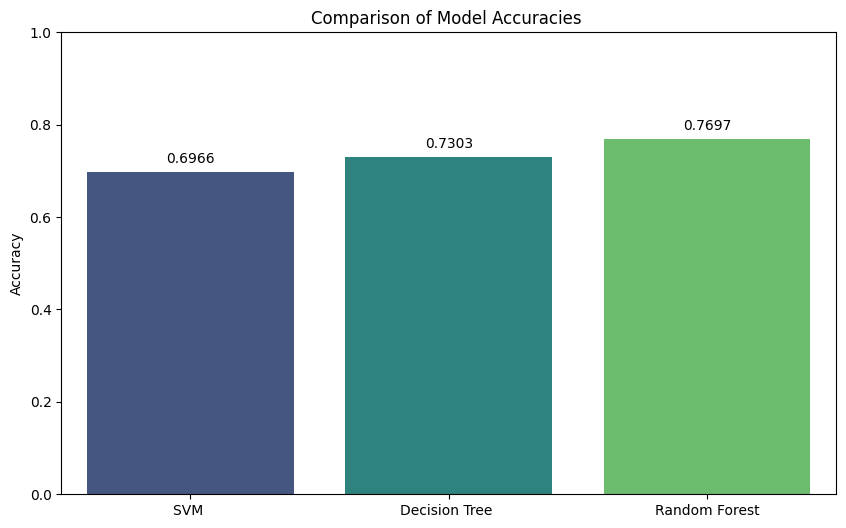

In [72]:
import numpy as np

# Get accuracies from the SMOTE-trained models
accuracy_svm_smote = accuracy_score(y_test, y_pred_svm_smote)
accuracy_dt_smote = accuracy_score(y_test, y_pred_dt_smote)
accuracy_rf_smote = accuracy_score(y_test, y_pred_rf_smote)

models_smote = ['SVM ', 'Decision Tree ', 'Random Forest']
accuracies_smote = [accuracy_svm_smote, accuracy_dt_smote, accuracy_rf_smote]

plt.figure(figsize=(10, 6))
sns.barplot(x=models_smote, y=accuracies_smote, palette='viridis', hue=models_smote, legend=False)
plt.title('Comparison of Model Accuracies ')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
for index, value in enumerate(accuracies_smote):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center')
plt.show()

In [4]:
import os

os.listdir()

['.config', 'sample_data']